# UK Biobank depletion score & LFC corr  
The lower the depletion rank is, the more constraints the region has

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pyranges as pr
import re
import scipy.stats as stats
from Bio import SeqIO
from scipy.stats import ks_2samp
from scipy.stats import pearsonr
from scipy.stats import spearmanr
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

from matplotlib import font_manager
import matplotlib as mpl

arial_path = "/media/scratch/fy2306/tools/fonts"
font_files = font_manager.findSystemFonts(fontpaths=arial_path)

for file in font_files:
    font_manager.fontManager.addfont(file)
    
mpl.rcParams['font.family'] = 'Arial'

import warnings
warnings.filterwarnings("ignore")

from scipy.stats import pearsonr
from scipy.stats import spearmanr
import re

In [2]:
id_prefix_list = [
	"MYC_GFP_"
]

In [3]:
# remove negative controls that can be mapped to the genome (with bowtie)
mapped_ctrl_path = "/media/scratch/fy2306/projects/base_editing/data/bowtie/all/all_sgrna_seqs.bowtie_hg38.mismatch1.processed.tsv"
mapped_ctrl_df = pd.read_csv(mapped_ctrl_path, sep="\t")
mapped_ctrl_df = mapped_ctrl_df[
    mapped_ctrl_df['id'].str.startswith(('Random', 'Non-targeting-controls', 'AAVS1'))
    & ~(mapped_ctrl_df['id'].str.startswith('AAVS1') & (mapped_ctrl_df['Alignments_NM0'] == 1) & (mapped_ctrl_df['Alignments_NM1'] == 0))
]
mapped_ctrl_list = mapped_ctrl_df["id"].tolist()
print(len(mapped_ctrl_list))
all_ctrl = [
    record.id for record in SeqIO.parse("/media/scratch/fy2306/projects/base_editing/data/bowtie/negative_controls/input/negative_controls.fa", "fasta")
    ]
clean_ctrl_list = list(set(all_ctrl)-set(mapped_ctrl_list))
print(len(clean_ctrl_list))
print(len(all_ctrl))

91
474
565


In [4]:
# randomly group nc sgrnas
def group_and_aggregate(df, group_size, random_state=None):
    df_shuffled = df.sample(frac=1, random_state=random_state).reset_index(drop=True)
    
    num_groups = len(df_shuffled) // group_size
    df_trimmed = df_shuffled.iloc[:num_groups * group_size]
    
    grouped = np.array_split(df_trimmed, num_groups)
    
    aggregated = []
    for group in grouped:
        sgrna_concat = ','.join(group['sgrna'].astype(str))
        avg_lfc = group['per time unit LFC'].mean()
        aggregated.append({
            'sgrna': sgrna_concat,
            'per time unit LFC': avg_lfc
        })
    
    return pd.DataFrame(aggregated)

UK Biobank depletion rank
4.989407589512111e-07


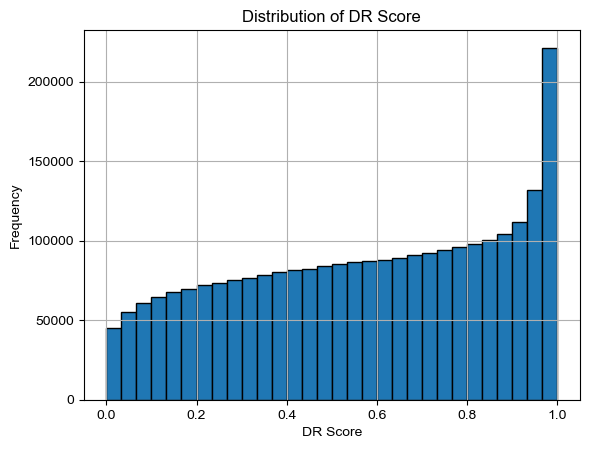

[4.98940759e-07 5.98424587e-01 9.99998951e-01]


In [5]:
score_path = "/media/rna/fy2306/ukbiobank_dr.chr8.tsv"
scores_df = pd.read_csv(score_path, sep="\t")

print("UK Biobank depletion rank")
print(scores_df['rank'].min())

plt.hist(scores_df['rank'], bins=30, edgecolor='black')
plt.xlabel('DR Score')
plt.ylabel('Frequency')
plt.title('Distribution of DR Score')
plt.grid(True)
plt.show()

_, bins = pd.qcut(scores_df['rank'], q=2, retbins=True)
print(bins)

In [6]:
def ukb_lfc_cdf(
	gene, myc_var, cons_col,
	date,
	test_name,
	nc_test_name,
	merge_method_nucleotide, 
	win_size,
	baseline,
	treatments,
	day_numbers,
	cons_subset,
	merge_method_replicate,
	conservation_threshold,
	title=None,
	per_time_unit=True, abs_LFC=False):

	score_path = "/media/rna/fy2306/ukbiobank_dr.chr8.tsv"

	# preprocess
	df_path = f"/media/scratch/fy2306/projects/base_editing/data/{date}/mageck/{test_name}/{merge_method_nucleotide}/myc_repeats/{win_size}/MYC_U1.gene_summary.txt"
	df = pd.read_csv(df_path, sep="\t")
	pattern = f"^({'|'.join(map(re.escape, id_prefix_list))})([0-9]*\.?[0-9]+)"
	df = df[df['id'].str.match(pattern)]
	edited_pos_chr_col = "indel_base_pos_chr"	# nucleotide pos
	df[edited_pos_chr_col] = df['id'].str.extract(pattern)[1].astype(int)	# 1-based

	# merge
	treatment_lfc_columns = [f"{treatment}_vs_{baseline}|neg|lfc" for treatment in treatments]
	treatment_fdr_columns = [f"{treatment}_vs_{baseline}|neg|fdr" for treatment in treatments]
	treatment_fdr_goodsgrna_columns = [f"{treatment}_vs_{baseline}|neg|goodsgrna" for treatment in treatments]
	treatment_fdr_pos_columns = [f"{treatment}_vs_{baseline}|pos|fdr" for treatment in treatments]
	treatment_fdr_pos_goodsgrna_columns = [f"{treatment}_vs_{baseline}|pos|goodsgrna" for treatment in treatments]

	if per_time_unit:
		for col, day in zip(treatment_lfc_columns, day_numbers):
			df[col] = df[col] / (day + 0) # per time unit.

	if merge_method_replicate == "mean":
		df["neg|lfc"] = df[treatment_lfc_columns].mean(axis=1)

	if abs_LFC:
		df["neg|lfc"] = df["neg|lfc"].abs()

	# copied from lfc_to_seq
	for fdr_col, goodsgrna_col in zip(treatment_fdr_columns, treatment_fdr_goodsgrna_columns):
		df.loc[df[goodsgrna_col] < 2, fdr_col] = 1
	df["neg|fdr"] = df[treatment_fdr_columns].apply(lambda row: sorted(row)[1], axis=1)	# second-lowest fdr
	df["direction"] = df[treatment_lfc_columns].apply(lambda row: (row.gt(0).all() or row.lt(0).all()), axis=1)
	for fdr_col, goodsgrna_col in zip(treatment_fdr_pos_columns, treatment_fdr_pos_goodsgrna_columns):
		df.loc[df[goodsgrna_col] < 2, fdr_col] = 1
	df["pos|fdr"] = df[treatment_fdr_pos_columns].apply(lambda row: sorted(row)[1], axis=1)	# second-lowest fdr
	df["fdr"] = df[["neg|fdr", "pos|fdr"]].min(axis=1)

	# add repeats
	rmsk_path = "/media/dna/fy2306/genomes/hg38/RepeatMasker/rmsk.txt"
	rmsk_colnames = ["bin", "swScore", "milliDiv", "milliDel", "milliIns", "genoName", "genoStart", "genoEnd", "genoLeft", "strand", "repName", "repClass", "repFamily", "repStart", "repEnd", "repLeft", "id"]
	rmsk = pd.read_csv(rmsk_path, sep="\t", header=None, names=rmsk_colnames)
	rmsk = rmsk[rmsk['genoName'] == "chr8"]
	# rmsk: 0-based
	rmsk_ranges = pr.PyRanges(rmsk.rename(columns={
	'genoName': 'Chromosome',
	'genoStart': 'Start',
	'genoEnd': 'End'
	}))

	# base_pos: 1-based
	df['Start'] = df[edited_pos_chr_col] - 1
	df['End'] = df['Start'] + 1
	df['Chromosome'] = 'chr8'

	df["orig_index"] = df.index
	df_ranges = pr.PyRanges(df[['Chromosome', 'Start', 'End', 'orig_index']])

	overlap = df_ranges.intersect(rmsk_ranges, how="containment")	# in pyranges: “containment” reports intervals where the overlapping is contained within it, gives you the intervals in self be completely within the intervals in other
	overlap_indices = overlap.df['orig_index'].unique()

	df["indel_repeats"] = False
	df.loc[overlap_indices, "indel_repeats"] = True

	df = df[["id", edited_pos_chr_col, "neg|lfc", "indel_repeats", "fdr", "direction"]]

	# process the negative controls
	df_nc = None
	for treatment in treatments:
		df_nc_path = f"/media/scratch/fy2306/projects/base_editing/data/{date}/mageck/{nc_test_name}/MYC_U1.{treatment}_vs_{baseline}.sgrna_summary.txt"
		df_nc_rep = pd.read_csv(df_nc_path, sep="\t", usecols=["sgrna", "Gene", "LFC"])
		df_nc_rep = df_nc_rep[df_nc_rep["Gene"].isin(["AAVS1", "NT", "Random"])]
		df_nc_rep = df_nc_rep.drop('Gene', axis=1)
		df_nc_rep = df_nc_rep.rename(columns={"LFC": f"LFC_{treatment}"})
		if df_nc is None:
			df_nc = df_nc_rep
		else:
			# Merge on 'sgrna'
			df_nc = pd.merge(df_nc, df_nc_rep, on="sgrna", how="inner")
	print(len(df_nc))

	treatment_lfc_nc_columns = [f"LFC_{treatment}" for treatment in treatments]

	if per_time_unit:
		for col, day in zip(treatment_lfc_nc_columns, day_numbers):
			df_nc[col] = df_nc[col] / (day + 0) # per time unit.

	if merge_method_replicate == "mean":
		df_nc["per time unit LFC"] = df_nc[treatment_lfc_nc_columns].mean(axis=1)

	# remove mismatches
	df_nc = df_nc[~(df_nc["sgrna"].isin(mapped_ctrl_list))]
	df_nc = df_nc[['sgrna', 'per time unit LFC']]

	# random group of df_nc
	n_repeats = 1000
	all_results = []

	for seed in range(n_repeats):
		df_nc_result = group_and_aggregate(df_nc, group_size=2*int(win_size), random_state=seed)
		all_results.append(df_nc_result)

	df_nc_combined = pd.concat(all_results, ignore_index=True)
	nc_combined_median_value = df_nc_combined["per time unit LFC"].median()
	print(nc_combined_median_value)

	df["neg|lfc"] = df["neg|lfc"] - nc_combined_median_value

	# add sig column
	df['sig'] = "Other"
	df.loc[(df['fdr'] < 0.05) & (df['direction'] == True), 'sig'] = "Significant"
	print(df['sig'].value_counts())

	# process uk biobank depletion rank
	conservation_scores = pd.read_csv(score_path, sep="\t")	# 0-based
	conservation_scores = conservation_scores.sort_values(['Chr', 'Fromx']).reset_index(drop=True)

	conservation_scores["Fromx"] = conservation_scores["Fromx"] + 1	# to 1-based
	conservation_scores[edited_pos_chr_col] = ((conservation_scores['Fromx'] + conservation_scores['To']) / 2).round().astype(int)
	# filter for myc 10kb locus
	conservation_scores = conservation_scores[(conservation_scores['Fromx'] >= 127734050) & (conservation_scores['To'] <= 127744100)].reset_index(drop=True)
	print(conservation_scores.head())

	def mean_neg_lfc(row):
		mask = (df[edited_pos_chr_col] >= row['Fromx']) & (df[edited_pos_chr_col] <= row['To'])
		vals = df.loc[mask, 'neg|lfc']
		# print(len(vals))
		return vals.mean() if not vals.empty else np.nan

	conservation_scores['neg|lfc'] = conservation_scores.apply(mean_neg_lfc, axis=1)
	conservation_scores = conservation_scores.dropna(subset=['neg|lfc'])

	# load in lib
	lib_path = f"/media/scratch/fy2306/projects/base_editing/data/grna_type/MYC-lib-for-mageck.type.{myc_var}.organized.txt"
	df_lib = pd.read_csv(lib_path, sep="\t", usecols=[edited_pos_chr_col, cons_col])
	df_lib = df_lib.drop_duplicates(subset=edited_pos_chr_col)
	df = pd.merge(df, df_lib, on=edited_pos_chr_col, how='left')
	# df = df[df["indel_repeats"] == False]
	# df: "id", edited_pos_chr_col, "neg|lfc", "indel_repeats", "chrom", "score", cons_col
	print(df[edited_pos_chr_col].duplicated().sum())
	# add promoter annotation
	df.loc[
		(df[edited_pos_chr_col] >= (127736084-1000)) & (df[cons_col] == 'upstream_flanking'),
		cons_col
		] = 'promoter'
	
	print(len(conservation_scores))

	def window_annotations(row):
		vals = df.loc[
			(df[edited_pos_chr_col] >= row["Fromx"]) &
			(df[edited_pos_chr_col] <= row["To"]),
			cons_col
		].dropna().unique()

		return set(vals)

	# def unique_window_annotations(row):
	# 	vals = df.loc[
	# 		(df[edited_pos_chr_col] >= row["Fromx"]) &
	# 		(df[edited_pos_chr_col] <= row["To"]),
	# 		cons_col
	# 	].dropna().unique()

	# 	if len(vals) == 1:
	# 		return set(vals)
	# 	return np.nan

	def window_repeat_bp_count(row):
		mask = (
			(df[edited_pos_chr_col] >= row["Fromx"]) &
			(df[edited_pos_chr_col] <= row["To"]) &
			(df["indel_repeats"] == True)
		)
		return df.loc[mask, edited_pos_chr_col].drop_duplicates().shape[0]

	def window_sig_bp_count(row):
		mask = (
			(df[edited_pos_chr_col] >= row["Fromx"]) &
			(df[edited_pos_chr_col] <= row["To"]) &
			(df["sig"] == "Significant")
		)
		return df.loc[mask, edited_pos_chr_col].drop_duplicates().shape[0]

	# window annotation: allow multi annotations
	conservation_scores[f"{cons_col}_set"] = conservation_scores.apply(window_annotations, axis=1)
	# # window annotation: unique annotations
	# conservation_scores[f"{cons_col}_set"] = conservation_scores.apply(unique_window_annotations, axis=1)
	# conservation_scores = conservation_scores.dropna(subset=[f"{cons_col}_set"])
	# window repeat annotation
	conservation_scores["repeat_bp_count"] = conservation_scores.apply(window_repeat_bp_count, axis=1)
	conservation_scores["window_repeat"] = conservation_scores["repeat_bp_count"] > 100
	# window significance annotation
	conservation_scores["sig_bp_count"] = conservation_scores.apply(window_sig_bp_count, axis=1)
	conservation_scores["window_sig"] = np.where(conservation_scores["sig_bp_count"] >= 19, "Significant", "Other")	# 343/9225*500
	conservation_scores = conservation_scores[
		conservation_scores[f"{cons_col}_set"].map(len) > 0
	]
	print(len(conservation_scores))
	# df = pd.merge(conservation_scores, df[[edited_pos_chr_col, cons_col, "indel_repeats"]], on=edited_pos_chr_col, how="inner")
	# print(len(df))
	df = conservation_scores
	df = df[df["window_repeat"] == False]

	
	if cons_subset != "all":
		cons_subset_set = set(cons_subset)

		df = df[
			df[f"{cons_col}_set"].map(lambda vals: set(vals).issubset(cons_subset_set))
		]

	if isinstance(conservation_threshold, float):
		conservation_threshold = conservation_threshold
	elif conservation_threshold == "mean":
		# mean of selected regions
		conservation_threshold = df['rank'].mean()
	elif conservation_threshold == "median":
		# median of selected regions
		conservation_threshold = df['rank'].median()
	print(f"conservation_threshold: {conservation_threshold}")

	bins = [float('-inf'), conservation_threshold, float('inf')]
	labels = [f'[0, {conservation_threshold:.2f})', f'[{conservation_threshold:.2f}, 1]']

	df['score_bin'] = pd.cut(df['rank'], bins=bins, labels=labels, right=False)
	print(df['score_bin'].value_counts())


	# cdf: split by conservation score
	plt.figure(figsize=(4,4))

	colors = {
		f"[0, {conservation_threshold:.2f})": "#FF0066",
		f"[{conservation_threshold:.2f}, 1]": "#66CCFE"
	}

	for label in labels:
		group_data = df[df['score_bin'] == label]['neg|lfc'].sort_values()
		if len(group_data) == 0:
			continue
		cdf = np.arange(1, len(group_data)+1) / len(group_data)
		
		plt.plot(group_data, cdf, label=f'DR {label}\n(N={len(group_data)})', color=colors[label])

	group_low = df[df['score_bin'] == f'[0, {conservation_threshold:.2f})']['neg|lfc']
	median_low = group_low.median()
	group_high = df[df['score_bin'] == f'[{conservation_threshold:.2f}, 1]']['neg|lfc']
	median_high = group_high.median()
	ks_stat, p_value = ks_2samp(group_low, group_high)

	shift = abs(median_high - median_low)

	if abs_LFC:
		plt.xlabel('500 bp window phenotype score (abs)', fontsize=14)
	else:
		plt.xlabel('500 bp window phenotype score', fontsize=14)
	plt.ylabel('CDF', fontsize=14)
	if title:
		plt.title(f"{title}", fontsize=13)
	else:
		plt.title(f"{cons_subset}\nKS stat={ks_stat:.3f}, p={p_value:.2e}, shift={shift:.2e}", fontsize=13)
	mant, exp = f"{p_value:.2e}".split("e")
	mant = float(mant); exp = int(exp)
	handles = [
		Line2D([], [], linestyle="None", marker=None, color=colors[f"[0, {conservation_threshold:.2f})"],
			label=f'Low DR (N={len(df[df.score_bin==f"[0, {conservation_threshold:.2f})"]):,})'),
		Line2D([], [], linestyle="None", marker=None, color=colors[f"[{conservation_threshold:.2f}, 1]"],
			label=f'High DR (N={len(df[df.score_bin==f"[{conservation_threshold:.2f}, 1]"]):,})'),
		Line2D([], [], linestyle="None", marker=None, color="black",
			label=rf"$P={mant:.2f}\times 10^{{{exp}}}$"),
		Line2D([], [], linestyle="None", marker=None, color="black",
			label=f'Threshold: DR {conservation_threshold:.2f}'),
	]
	plt.legend(handles=handles, loc="upper left", frameon=False, fontsize=13,
			handlelength=0, handletextpad=0, labelcolor="linecolor")
	plt.yticks([0, 0.5, 1], fontsize=13)
	plt.xticks(fontsize=13)
	xmin = df[df["score_bin"].isin(labels)]["neg|lfc"].quantile(0.03)
	xmax = df[df["score_bin"].isin(labels)]["neg|lfc"].quantile(0.97)
	plt.xlim(xmin, xmax)
	plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(0.01))
	# plt.axvline(x = 0, color='grey', linestyle="--", alpha=0.5)
	# plt.axhline(y = 0.5, color='grey', linestyle="--", alpha=0.5)
	plt.gca().spines['top'].set_visible(False)
	plt.gca().spines['right'].set_visible(False)
	plt.grid(False)
	plt.savefig(f"/media/scratch/fy2306/projects/base_editing/plots/conservation/ukb_cdf.{title}.thresh{conservation_threshold:.2f}.pdf", 
				bbox_inches="tight",
				dpi=300,              
				transparent=True,
				format='pdf')
	plt.show()

	# cdf: split by sig
	plt.figure(figsize=(4,4))

	colors = {
		"Other": "#66CCFE",
		"Significant": "#FF0066"
	}

	for label in ["Significant", "Other"]:
		group_data = df[df['window_sig'] == label]['rank'].sort_values()
		if len(group_data) == 0:
			continue
		cdf = np.arange(1, len(group_data)+1) / len(group_data)

		plt.plot(group_data, cdf, label=f"{label} (N={len(group_data):,})", color=colors[label])

	group_low = df[df['window_sig'] == 'Other']['rank']
	median_low = group_low.median()
	group_high = df[df['window_sig'] == 'Significant']['rank']
	median_high = group_high.median()
	ks_stat, p_value = ks_2samp(group_low, group_high)

	shift = abs(median_high - median_low)

	plt.xlabel('Human constraints (UKB DR)', fontsize=14)
	plt.ylabel('CDF', fontsize=14)
	if title:
		plt.title(f"{title}", fontsize=13)
	else:
		plt.title(f"{cons_subset}\nKS stat={ks_stat:.3f}, p={p_value:.2e}, shift={shift:.2e}", fontsize=13)
	mant, exp = f"{p_value:.2e}".split("e")
	mant = float(mant); exp = int(exp)
	handles = [
		Line2D([], [], linestyle="None", marker=None, color=colors["Significant"],
			label=f'Significant (N={len(df[df.window_sig=="Significant"]):,})'),
		Line2D([], [], linestyle="None", marker=None, color=colors["Other"],
			label=f'Other (N={len(df[df.window_sig=="Other"]):,})'),
		Line2D([], [], linestyle="None", marker=None, color="black",
			label=rf"$P={mant:.2f}\times 10^{{{exp}}}$"),
	]
	plt.legend(handles=handles, loc="upper left", frameon=False, fontsize=13,
			handlelength=0, handletextpad=0, labelcolor="linecolor")

	plt.yticks([0, 0.5, 1], fontsize=13)
	plt.xticks(fontsize=13)
	plt.xlim(0, 1)
	# plt.axvline(x = 0, color='grey', linestyle="--", alpha=0.5)
	# plt.axhline(y = 0.5, color='grey', linestyle="--", alpha=0.5)
	plt.gca().spines['top'].set_visible(False)
	plt.gca().spines['right'].set_visible(False)
	plt.grid(False)
	plt.savefig(f"/media/scratch/fy2306/projects/base_editing/plots/conservation/ukb_cdf.{title}.sig.pdf", 
				bbox_inches="tight",
				dpi=300,              
				transparent=True,
				format='pdf')
	plt.show()

	# correlation - scatter plot
	print(len(df))	# ~200=10000/50
	r, p = pearsonr(df['rank'], df['neg|lfc'])
	# r, p = spearmanr(merged_df["LFC_d8"], merged_df["LFC_d20"])
	print(f"Pearson r: {r:.3f}, p-value: {p:.3e}")

	fig, ax = plt.subplots(figsize=(4, 4))

	ax.scatter(
		df['rank'],
		df['neg|lfc'],
		c='#AA66FF', alpha=0.8, s=10
	)

	sns.despine(ax=ax, top=True, right=True)
	ax.set_xlim(0, 1)
	ax.set_ylim(-0.02, 0.01)
	ax.set_xticks([0, 0.5, 1])
	ax.set_yticks([-0.01, 0, 0.01])
	ax.tick_params(labelsize=12)
	ax.set_xlabel("Human constraints (UKB DR)", fontsize=12)
	ax.set_ylabel("500 bp window phenotype score", fontsize=12)
	ax.set_title(title, fontsize=12)

	ax.text(
		0.05, 0.98,
		f"Pearson r = {r:.2f}\n(p = {p:.2e})",
		transform=ax.transAxes,
		fontsize=12,
		verticalalignment='top',
		horizontalalignment='left'
	)

	ax.spines['top'].set_visible(False)
	ax.spines['right'].set_visible(False)

	plt.tight_layout()
	plt.savefig(f"/media/scratch/fy2306/projects/base_editing/plots/conservation/ukb_corr.{title}.pdf", 
				bbox_inches="tight",
				dpi=300,              
				transparent=True,
				format='pdf')
	plt.show()

565
-0.0028773212890625005
sig
Other          9532
Significant     523
Name: count, dtype: int64
    Chr      Fromx         To      rank  indel_base_pos_chr
0  chr8  127734051  127734550  0.166884           127734300
1  chr8  127734101  127734600  0.123137           127734350
2  chr8  127734151  127734650  0.098051           127734400
3  chr8  127734201  127734700  0.074694           127734450
4  chr8  127734251  127734750  0.067614           127734500
0
192
192
conservation_threshold: 0.4714269660903161
score_bin
[0, 0.47)    60
[0.47, 1]    60
Name: count, dtype: int64


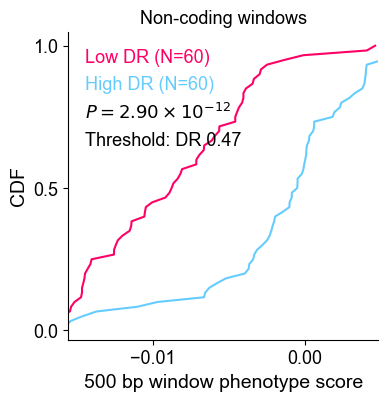

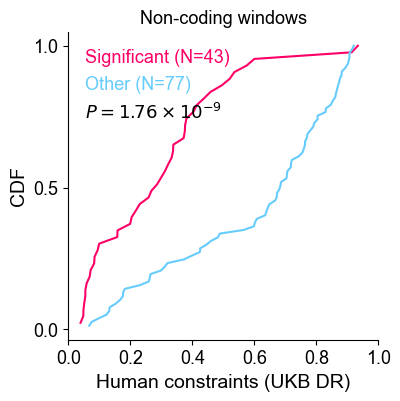

120
Pearson r: 0.523, p-value: 9.272e-10


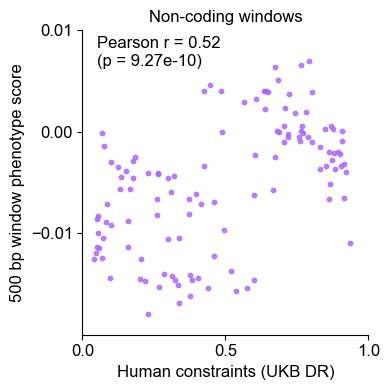

In [7]:
gene = "MYC"
myc_var = "myc2_indel"
cons_col = "indel_consequences_more"
date = "20250416"
test_name = "test-1-standard-nucleotide/test"
nc_test_name = "test-1-standard/test"
merge_method_nucleotide = "mean"
win_size = "4"
baseline = "Cas9-HMOI_D0"
treatments = ["Cas9-LMOI_D20", "Cas9-LMOI_D8", "Cas9_SpRY_L_MOI_D_20", "Cas9_SpRY_L_MOI_D_8"]
day_numbers = [20, 8, 20, 8]
# cons_subset = ["upstream_flanking", "promoter", "5_prime_UTR", "intron_1", "intron_2", "intron_splice", "3_prime_UTR", "coding", "downstream_flanking"]
cons_subset = ["upstream_flanking", "promoter", "5_prime_UTR", "intron_1", "intron_2", "intron_splice", "3_prime_UTR", "downstream_flanking"]
merge_method_replicate = "mean"
conservation_threshold = "median"
ukb_lfc_cdf(
	gene, myc_var, cons_col,
	date,
	test_name,
	nc_test_name,
	merge_method_nucleotide, 
	win_size,
	baseline,
	treatments,
	day_numbers,
	cons_subset,
	merge_method_replicate,
	conservation_threshold,
	title="Non-coding windows",
	per_time_unit=True, abs_LFC=False)